# Week 2 - Ungraded Lab: A Journey through Data

The paradigm behind machine learning is shifting from model-centric to data-centric. In this lab, you will see how data preparation affects the output of your models. You will build an image classifier that detects three classes: dog, cat, and bird. To demonstrate the effect of your input data, you will only use a single model throughout -- a simple Convolutional Neural Network (CNN) -- and will only vary the dataset. You will navigate common problems such as class imbalance and overfitting, and will walk through useful diagnosis tools and methods to mitigate these issues.


## Lab Setup

This lab comes with some extra files as you see in the file explorer on the left:

* `data` folder: You will be using a combination of the [Cats vs. Dogs](https://www.microsoft.com/en-us/download/details.aspx?id=54765) and [Caltech Birds](https://www.vision.caltech.edu/datasets/cub_200_2011/) datasets. These are extracted in the `data/images` folder.

* `lab_utils.py`: This contains helper functions for this lab. Feel free to explore this file if you want to see how they are implemented.

**A note on this version of the lab:** this is a self-contained copy of the original DeepLearning.AI ungraded lab, rebuilt to run outside of the Coursera environment so it doesn't depend on any platform-specific setup. The original version could optionally skip training and load pretrained models/histories provided by Coursera -- this version always trains from scratch instead, since those pretrained files aren't available here. Training the three models yourself takes roughly 3, 5, and 20 minutes respectively (faster with a GPU); the rest of the lab -- code, structure, and explanations -- is unchanged.

**Before running this notebook**, download the two datasets (see the links above, or ask your instructor for direct download links) and arrange them as:
```
data/images/dog/    <- dog photos
data/images/cat/    <- cat photos
data/images/bird/   <- bird photos
```


### Running this notebook in Google Colab

If you're running this in Google Colab, run the cell below first. It downloads this entire repository (the notebook, `lab_utils.py`, and the full dataset) into your Colab session, so nothing else in the notebook below needs to change.

If you're running this locally instead (not in Colab), skip the cell below.

In [ ]:
# Run this cell only if you're in Google Colab
!git clone https://github.com/Rachietaa/Data-Centric-AI-Lab-materials.git
%cd Data-Centric-AI-Lab-materials

# Quick check that everything landed correctly
import os
print(os.listdir('.'))
print(os.listdir('./data/images'))

You will now import the packages needed in this lab.

In [1]:
import os
import gc
import tarfile
import numpy as np
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
import lab_utils
import tensorflow as tf
from IPython.display import Image, display


You will also define some global variables that you will use throughout the lab.

In [2]:
# Directory containing the raw data
DATA_DIR = './data'

# Base directory for preparing the datasets for training and evaluation
DATA_SPLITS = './data_splits'

# Name of the classes to predict
ANIMALS = ['dogs', 'cats', 'birds']

# Directories for the training and dev sets
TRAIN_DIRS = ['train/dogs', 'train/cats', 'train/birds']
DEV_DIRS = ['dev/dogs', 'dev/cats', 'dev/birds']

# Imbalanced portion of images among the 3 classes
PORTIONS = [0.2, 1, 0.1]


## A story of data

Throughout this lab, you will simulate a real life scenario:

You have been tasked with creating a model that classifies images of cats, dogs and birds. To establish a baseline, you settle on a simple Convolutional Neural Network (CNN) architecture since CNNs are known to perform well on image classification tasks. You thought of using two widely used datasets: `cats vs dogs`, and `caltech birds` to train your model.

_Note: Both datasets are also available through [TensorFlow Datasets (TFDS)](https://github.com/tensorflow/datasets). For this lab however, you will prepare the datasets yourself so that you have more control over the manipulations._


The dataset has an `images` top-level directory and has 3 subdirectories for each class: `dog`, `cat`, and `bird`.

In [3]:
os.listdir(DATA_DIR)

['images']

In [4]:
os.listdir(f'{DATA_DIR}/images')

['cat', 'dog', 'bird']

You will assign these to variables and check how many images are in each subdirectory.

In [5]:
base_dogs_dir = os.path.join(DATA_DIR, 'images/dog')
base_cats_dir = os.path.join(DATA_DIR,'images/cat')
base_birds_dir = os.path.join(DATA_DIR,'images/bird')
base_image_dirs = [base_dogs_dir, base_cats_dir, base_birds_dir]

for animal, base_image_dir in zip(ANIMALS, base_image_dirs):
    print(f"There are {len(os.listdir(base_image_dir))} images of {animal}")


There are 1333 images of dogs
There are 1333 images of cats
There are 1189 images of birds


It turns out that there is a similar number of images for each class you are trying to predict. This will likely lead to your model having the same performance on all three classes.

Take a quick look at an image from each class.

Sample cat image:


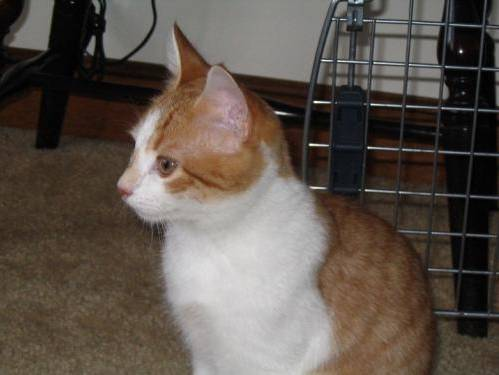


Sample dog image:


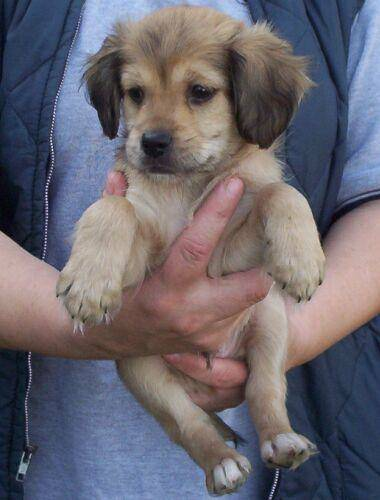


Sample bird image:


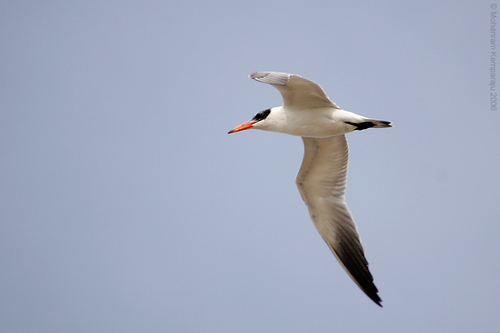

In [6]:
print("Sample cat image:")
display(Image(filename=f"{os.path.join(base_cats_dir, os.listdir(base_cats_dir)[0])}"))
print("\nSample dog image:")
display(Image(filename=f"{os.path.join(base_dogs_dir, os.listdir(base_dogs_dir)[0])}"))
print("\nSample bird image:")
display(Image(filename=f"{os.path.join(base_birds_dir, os.listdir(base_birds_dir)[0])}"))


## Train / Dev Split

Before training the model, you need to split the data into training and dev sets. For training, you will use the [`Keras`](https://keras.io) application programming interface (API) which includes functionality to read images from various directories.

Run the next cell to create the directories for training and dev sets.


In [7]:
for dir in TRAIN_DIRS:
    os.makedirs(os.path.join(DATA_SPLITS, dir), exist_ok=True)

for dir in DEV_DIRS:
    os.makedirs(os.path.join(DATA_SPLITS, dir), exist_ok=True)


Notice that there are now `train` and `dev` directories in the `data_splits` directory.

In [8]:
os.listdir(DATA_SPLITS)

['imbalanced', 'train', 'dev']

Moreover, these have subdirectories for each class.

In [9]:
os.listdir(os.path.join(DATA_SPLITS, 'train'))

['dogs', 'cats', 'birds']

In [10]:
os.listdir(os.path.join(DATA_SPLITS, 'dev'))

['dogs', 'cats', 'birds']

You will move a percentage of images from an origin folder to a destination folder as desired to generate the training and dev splits. You will use the `split_copy` function from `lab_utils` for this step. This will take a couple of minutes to run, depending on how many images you downloaded.

In [11]:
# Set 70% of the images for training. The remaining 30% for dev.
for base_dir, train_dir, dev_dir in zip(base_image_dirs, TRAIN_DIRS, DEV_DIRS):
    lab_utils.split_copy(
        base_dir,
        os.path.join(DATA_SPLITS, train_dir),
        os.path.join(DATA_SPLITS, dev_dir),
        train_ratio=0.7
    )


Check how many images you have available for each split and class:

In [12]:
for animal, train_dir in zip(ANIMALS, TRAIN_DIRS):
    print(f"There are {len(os.listdir(os.path.join(DATA_SPLITS, train_dir)))} images of {animal} for training")

print()

for animal, dev_dir in zip(ANIMALS, DEV_DIRS):
    print(f"There are {len(os.listdir(os.path.join(DATA_SPLITS, dev_dir)))} images of {animal} for evaluation")


There are 933 images of dogs for training
There are 933 images of cats for training
There are 832 images of birds for training

There are 400 images of dogs for evaluation
There are 400 images of cats for evaluation
There are 357 images of birds for evaluation


## An unexpected issue!

Let's face the first real life issue in this narrative! There was a power outage in your office and some hard drives were damaged. As a result of the damage, many of the images for `dogs` and `birds` have been erased. As a matter of fact, only 20% of the dog images and 10% of the bird images survived.

To simulate this scenario, create a new directory called `imbalanced` and copy only the portions mentioned above for each class.


In [13]:
for dir in TRAIN_DIRS + DEV_DIRS:
    os.makedirs(os.path.join(DATA_SPLITS, 'imbalanced/'+dir), exist_ok=True)


In [14]:
# Perform the copying
for train_dir, portion in zip(TRAIN_DIRS, PORTIONS):
    lab_utils.copy_with_limit(
        os.path.join(DATA_SPLITS, train_dir),
        os.path.join(DATA_SPLITS, f'imbalanced/{train_dir}'),
        portion
    )

for dev_dir, portion in zip(DEV_DIRS, PORTIONS):
    lab_utils.copy_with_limit(
        os.path.join(DATA_SPLITS, dev_dir),
        os.path.join(DATA_SPLITS, f'imbalanced/{dev_dir}'),
        portion
    )


Now, check the images for each split and class again. You'll notice that the images are now imbalanced, where the cat pictures dominate the dataset.

In [15]:
# Print number of available images
for animal, train_dir in zip(ANIMALS, TRAIN_DIRS):
    print(f"There are {len(os.listdir(os.path.join(DATA_SPLITS, f'imbalanced/{train_dir}')))} images of {animal} for training")

print()

for animal, dev_dir in zip(ANIMALS, DEV_DIRS):
    print(f"There are {len(os.listdir(os.path.join(DATA_SPLITS, f'imbalanced/{dev_dir}')))} images of {animal} for evaluation")


There are 186 images of dogs for training
There are 933 images of cats for training
There are 83 images of birds for training

There are 80 images of dogs for evaluation
There are 400 images of cats for evaluation
There are 35 images of birds for evaluation


For now there is no quick or clear solution to remedy the accidental file loss. You decide to keep going and train the model with the remaining images.

## Selecting the model

Use the `lab_utils.create_model()` function to create a model and define a loss function, optimizer and performance metrics leveraging the Keras API. You can print out the model summary as a quick check.


In [16]:
# Create a model to use with the imbalanced dataset
imbalanced_model = lab_utils.create_model()

# Print the model's summary
print(imbalanced_model.summary())


/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,343,491 (12.75 MB)

 Trainable params: 3,343,491 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

None


## Preparing the Data

You will use the [tf.data API](https://www.tensorflow.org/guide/data) to prepare the datasets so it can be consumed by the model.

The [image_dataset_from_directory() utility](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory) allows reading images from a base directory and outputs a [tf.data.Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset). You will pass in the following arguments:

- `directory`: Path to the root directory where the images are stored. In this case, you'll be pulling from the `imbalanced` train and dev directories.
- `image_size`: The dimensions to which all images found will be resized. Since images come in all kinds of resolutions, you need to standardize their size. 150x150 is used here, but other values should work well too.
- `batch_size`: Number of images the generator yields every time it is asked for a next batch. 32 is used here.
- `label_mode`: How the labels are represented. Here `int` is used to indicate that labels will be 1D. This is done for compatibility with the loss and evaluation metrics used when compiling the model.


In [17]:
# Instantiate the Dataset object for the training set
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_SPLITS,'imbalanced/train'),
    image_size=(150, 150),
    batch_size=32,
    label_mode='int'
    )

# Instantiate the Dataset object for the dev set
dev_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_SPLITS,'imbalanced/dev'),
    image_size=(150, 150),
    batch_size=32,
    label_mode='int'
    )


Found 1202 files belonging to 3 classes.
Found 515 files belonging to 3 classes.


Images are usually normalized to help with the model learning. You will use the [Rescaling](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling) preprocessing layer to transform the raw image pixels into the range `[0,1]`.

In [18]:
# Define the layer to normalize the images
rescale_layer = tf.keras.layers.Rescaling(1./255)

# Apply the layer to the datasets
train_dataset_scaled = train_dataset.map(lambda image, label: (rescale_layer(image), label))
dev_dataset_scaled = dev_dataset.map(lambda image, label: (rescale_layer(image), label))


You will chain in a few more methods to the datasets. In addition to shuffling the training set, using the [cache()](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#cache) and [prefetch()](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch) will help speed up the training.

In [19]:
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE

train_dataset_final = (train_dataset_scaled
                       .cache()
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                      )

dev_dataset_final = (dev_dataset_scaled
                            .cache()
                            .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                           )


## Training a CNN with class imbalanced data

In [20]:
# Create a model to use with the imbalanced dataset
imbalanced_model = lab_utils.create_model()

imbalanced_history = imbalanced_model.fit(
    train_dataset_final,
    epochs=10,
    validation_data=dev_dataset_final
    )


Epoch 1/10


/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.7220 - sparse_categorical_accuracy: 0.7596 - val_loss: 0.6936 - val_sparse_categorical_accuracy: 0.7767
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.6313 - sparse_categorical_accuracy: 0.7787 - val_loss: 0.6879 - val_sparse_categorical_accuracy: 0.7786
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.5821 - sparse_categorical_accuracy: 0.7953 - val_loss: 0.6478 - val_sparse_categorical_accuracy: 0.7806
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.5509 - sparse_categorical_accuracy: 0.8003 - val_loss: 0.6653 - val_sparse_categorical_accuracy: 0.7748
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.5385 - sparse_categorical_accuracy: 0.7995 - val_loss: 0.6167 - val_sparse_categorical_accuracy: 0.7748
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.5064 - sparse_categorical_accuracy: 0.8045 - val_loss: 0.6375 - val_sparse_categorical_accuracy: 0.7728
Epoch 7/10
38/3

To analyze the model performance properly, it is important to track different metrics such as accuracy and loss during the training process. Plot the metrics and losses for each training epoch using the `lab_utils.plot_train_eval()` helper function.

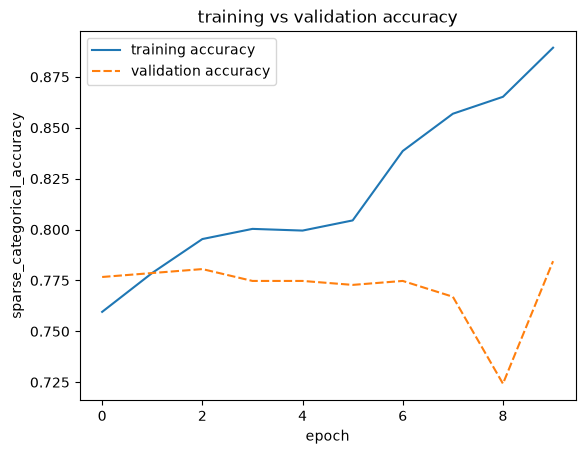

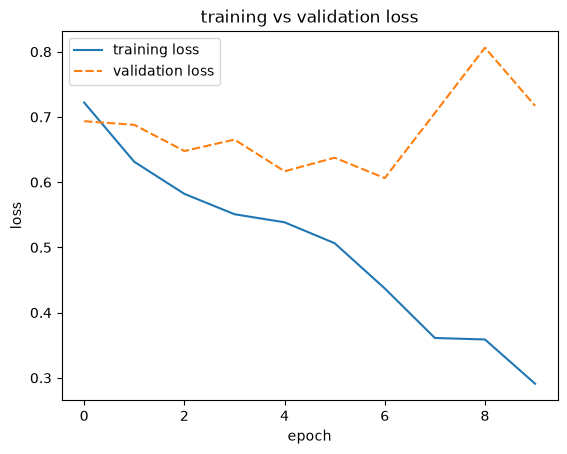

In [21]:
lab_utils.plot_train_eval(imbalanced_history)

From these two plots, it's evident that the model is overfitting the training data. However, the validation accuracy is still pretty high. Maybe class imbalance is not such a big issue after all. Perhaps this is too good to be true.

Let's dive a little deeper, and compute some additional metrics to explore if the class imbalance is hampering the model to perform well. In particular, let's compare: the [accuracy score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), the [balanced accuracy score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html), and the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [22]:
# Get the true labels from the dev set
y_true = dev_dataset_final.map(lambda image, label: label).unbatch()
y_true = list(y_true)

# Use the model to predict. This will take about a minute
predictions_imbalanced = imbalanced_model.predict(dev_dataset_final)

# Get the argmax (since softmax is being used)
y_pred_imbalanced = np.argmax(predictions_imbalanced, axis=1)

# Print accuracy score
print(f"Accuracy Score: {accuracy_score(y_true, y_pred_imbalanced)}")

# Print balanced accuracy score
print(f"Balanced Accuracy Score: {balanced_accuracy_score(y_true, y_pred_imbalanced)}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Accuracy Score: 0.7844660194174757
Balanced Accuracy Score: 0.45821428571428574


Comparing the `accuracy` and `balanced accuracy` metrics, the class imbalance starts to become apparent. Now, compute the `confusion matrix` of the predictions. Notice that the class imbalance is also present in the dev set, so the confusion matrix will show an overwhelming majority of predictions for cats.

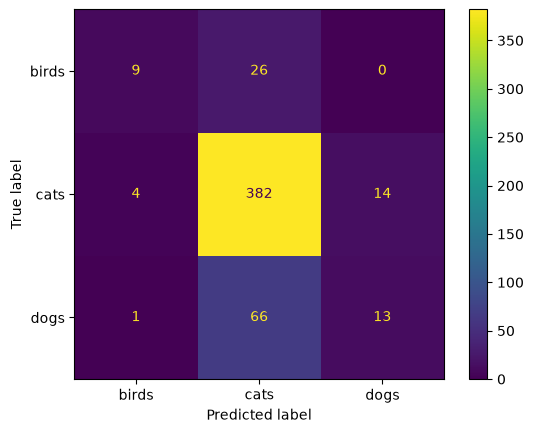

In [23]:
imbalanced_cm = confusion_matrix(y_true, y_pred_imbalanced)

ConfusionMatrixDisplay(imbalanced_cm, display_labels=['birds', 'cats', 'dogs']).plot(values_format="d")


If you show the misclassified images per class, you'll notice that the model expectedly does well for cats but not so much for birds and dogs.

In [24]:
misclassified_birds = (imbalanced_cm[0, 1] + imbalanced_cm[0, 2])/np.sum(imbalanced_cm, axis=1)[0]
misclassified_cats = (imbalanced_cm[1, 0] + imbalanced_cm[1, 2])/np.sum(imbalanced_cm, axis=1)[1]
misclassified_dogs = (imbalanced_cm[2, 0] + imbalanced_cm[2, 1])/np.sum(imbalanced_cm, axis=1)[2]

print(f"Proportion of misclassified birds: {misclassified_birds*100:.2f}%")
print(f"Proportion of misclassified cats: {misclassified_cats*100:.2f}%")
print(f"Proportion of misclassified dogs: {misclassified_dogs*100:.2f}%")


Proportion of misclassified birds: 74.29%
Proportion of misclassified cats: 4.50%
Proportion of misclassified dogs: 83.75%


Class imbalance is a real problem. If it's not detected early on, it can give the wrong impression that your model is performing better than it actually is. For this reason, it is important to rely on several metrics that do a better job at capturing these kinds of issues. **In this case, the overall `accuracy` metric is misleading** because the good results for the dominant class (i.e. cats) hide the poor results in the other two.

To prove this point further, consider a model that only predicts cats:


In [25]:
# Predict cat for all images
all_cats = np.ones(len(y_true))

# Print accuracy score
print(f"Accuracy Score: {accuracy_score(y_true, all_cats)}")

# Print balanced accuracy score
print(f"Balanced Accuracy Score: {balanced_accuracy_score(y_true, all_cats)}")


Accuracy Score: 0.7766990291262136
Balanced Accuracy Score: 0.3333333333333333


If you only look at the `accuracy` metric, the model seems to be working fairly well, since the majority class is the same that the model always predicts.

To address class imbalance, you can simply gather more data or use other techniques. For instance, [SMOTE](https://arxiv.org/pdf/1106.1813.pdf) oversamples the minority classes by creating synthetic data. However, these techniques are outside the scope of this lab.

Before moving forward, you can free up some memory by running the next cell.


In [26]:
# Delete unused variables
del train_dataset
del dev_dataset
del train_dataset_scaled
del dev_dataset_scaled
del train_dataset_final
del dev_dataset_final
del imbalanced_history
del imbalanced_model
del y_true
del predictions_imbalanced
del y_pred_imbalanced
del all_cats

# Call the Python garbage collector to free memory
gc.collect()


9600

# Training with the complete dataset

For the time being and following the narrative, assume that a colleague of yours was careful enough to save a backup of the complete dataset in her cloud storage. Now you can try training without the class imbalance issue. What a relief!

You will now train the model with the balanced dataset.


In [27]:
# Instantiate the Dataset object for the training set
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_SPLITS,'train'),
    image_size=(150, 150),
    batch_size=32,
    label_mode='int'
    )

# Instantiate the Dataset object for the dev set
dev_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_SPLITS,'dev'),
    image_size=(150, 150),
    batch_size=32,
    label_mode='int'
    )

# Define the layer to normalize the images
rescale_layer = tf.keras.layers.Rescaling(1./255)

# Apply the layer to the datasets
train_dataset_scaled = train_dataset.map(lambda image, label: (rescale_layer(image), label))
dev_dataset_scaled = dev_dataset.map(lambda image, label: (rescale_layer(image), label))

train_dataset_final = train_dataset_scaled.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
dev_dataset_final = dev_dataset_scaled.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 2698 files belonging to 3 classes.
Found 1157 files belonging to 3 classes.


In [28]:
# Create a model to use with the balanced dataset
balanced_model = lab_utils.create_model()

balanced_history = balanced_model.fit(
    train_dataset_final,
    epochs=10,
    validation_data=dev_dataset_final)


Epoch 1/10


/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.9965 - sparse_categorical_accuracy: 0.4711 - val_loss: 0.8496 - val_sparse_categorical_accuracy: 0.5851
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.7775 - sparse_categorical_accuracy: 0.6323 - val_loss: 0.8116 - val_sparse_categorical_accuracy: 0.6111
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.7206 - sparse_categorical_accuracy: 0.6449 - val_loss: 0.7043 - val_sparse_categorical_accuracy: 0.6543
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.6411 - sparse_categorical_accuracy: 0.7057 - val_loss: 0.6793 - val_sparse_categorical_accuracy: 0.6707
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.5915 - sparse_categorical_accuracy: 0.7279 - val_loss: 0.6865 - val_sparse_categorical_accuracy: 0.6785
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.5111 - sparse_categorical_accuracy: 0.7776 - val_loss: 0.6703 - val_sparse_categorical_accuracy: 0.6949
Epoch 7/10
85/

Let's check how the `accuracy` vs `balanced accuracy` comparison looks like now:

In [29]:
# Get the true labels
y_true = dev_dataset_final.map(lambda image, label: label).unbatch()
y_true = list(y_true)

# Use the model to predict (will take a couple of minutes)
predictions_balanced = balanced_model.predict(dev_dataset_final)

# Get the argmax (since softmax is being used)
y_pred_balanced = np.argmax(predictions_balanced, axis=1)

# Print accuracy score
print(f"Accuracy Score: {accuracy_score(y_true, y_pred_balanced)}")

# Print balanced accuracy score
print(f"Balanced Accuracy Score: {balanced_accuracy_score(y_true, y_pred_balanced)}")


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Accuracy Score: 0.6750216076058773
Balanced Accuracy Score: 0.6770308123249299


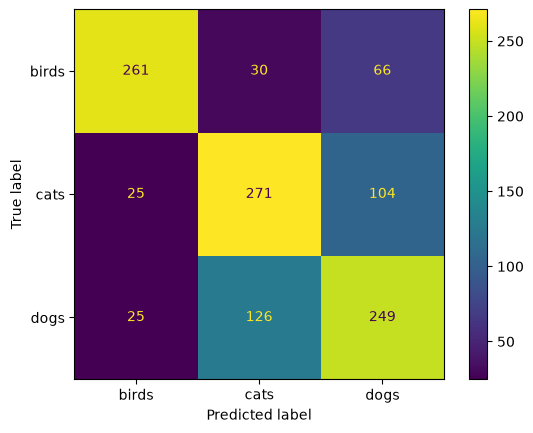

In [30]:
balanced_cm = confusion_matrix(y_true, y_pred_balanced)
ConfusionMatrixDisplay(balanced_cm, display_labels=['birds', 'cats', 'dogs']).plot(values_format="d")


Both accuracy-based metrics are very similar now. The confusion matrix also looks way better than before. This result suggests that class imbalance has been successfully mitigated by adding more data to the previously undersampled classes.\n\nNow that you know that you can trust the `accuracy` metric, plot the training history:

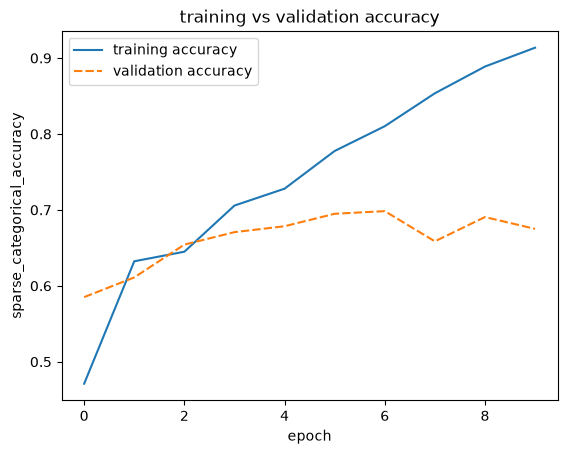

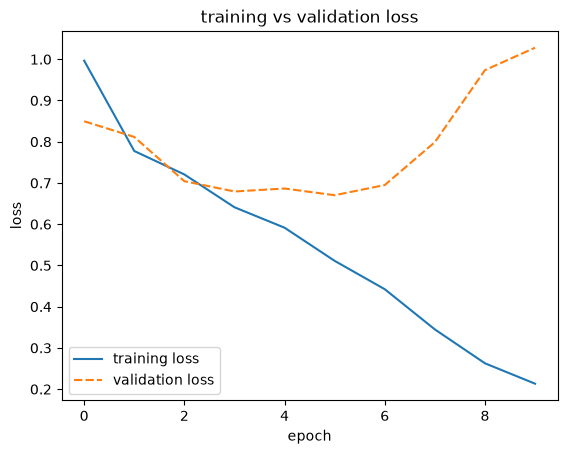

In [31]:
lab_utils.plot_train_eval(balanced_history)

This looks better than the earlier graphs for the imbalanced case. However, overfitting is still present.

Can you think of ways to address this issue? If you are familiar with CNNs, you might think of adding [Dropout](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) layers. This intuition is correct, but for now, you decide to stick with the same model and only change the data to see if it is possible to mitigate overfitting this way.

Keeping the model constant, one other possible solution to address overfitting is to apply data augmentation. Your whole team agrees this is the way to go so you decide to try this next.

Before moving forward, you can free up some memory by running the next cell.


In [32]:
# Delete unused variables
del train_dataset
del dev_dataset
del train_dataset_scaled
del dev_dataset_scaled
del train_dataset_final
del dev_dataset_final
del balanced_history
del balanced_model
del y_true
del predictions_balanced
del y_pred_balanced

# Call the Python garbage collector to free memory
gc.collect()


12799

# Training with Data Augmentation

Augmenting images is a technique where you create new versions of existing images in the dataset by applying geometric transformations. These transformations can vary from zooming in and out, rotating, or even flipping the images. By performing these transformations, you get a training dataset that exposes the model to a wider variety of images. This technique helps to further explore the feature space and hence reduce the chance of overfitting.

It is also a very natural idea since doing slight (or sometimes not so slight) changes to an image will result in an equally valid image. A cat sitting in an awkward position is still a cat, right?

You can do data augmentation in Keras by using [image augmentation layers](https://keras.io/api/layers/preprocessing_layers/image_augmentation/). These are only active during training and will automatically be bypassed during model prediction. The cell below creates a data augmentation model that flips, rotates, translates, and zooms the images randomly.


In [33]:
# Define fill mode.
FILL_MODE = 'nearest'

# Create the augmentation model.
data_augmentation = tf.keras.Sequential([

        # Specify the input shape on the first layer.
        tf.keras.layers.RandomFlip("horizontal", input_shape=(150,150,3)),
        tf.keras.layers.RandomRotation(0.2, fill_mode=FILL_MODE),
        tf.keras.layers.RandomTranslation(0.2,0.2, fill_mode=FILL_MODE),
        tf.keras.layers.RandomZoom(0.2, fill_mode=FILL_MODE)

        ]
)


/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


You can pass in some images to the `lab_utils.demo_augmentation()` function and see how they are transformed by these layers. First, get a sample batch from the training dataset and put the images in a list.

In [34]:
# Instantiate the Dataset object for the training set
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_SPLITS,'train'),
    image_size=(150, 150),
    batch_size=32,
    label_mode='int'
    )

# Instantiate the Dataset object for the dev set
dev_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_SPLITS,'dev'),
    image_size=(150, 150),
    batch_size=32,
    label_mode='int'
    )

# Define the layer to normalize the images
rescale_layer = tf.keras.layers.Rescaling(1./255)

# Apply the layer to the datasets
train_dataset_scaled = train_dataset.map(lambda image, label: (rescale_layer(image), label))
dev_dataset_scaled = dev_dataset.map(lambda image, label: (rescale_layer(image), label))

train_dataset_final = train_dataset_scaled.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
dev_dataset_final = dev_dataset_scaled.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 2698 files belonging to 3 classes.
Found 1157 files belonging to 3 classes.


In [35]:
# Get a batch of images
sample_batch = list(train_dataset.take(1))[0][0]
print(f'images per batch: {len(sample_batch)}')


images per batch: 32


Then pass some images from this list to the utility function. The cell below modifies the original images four times and previews the results.

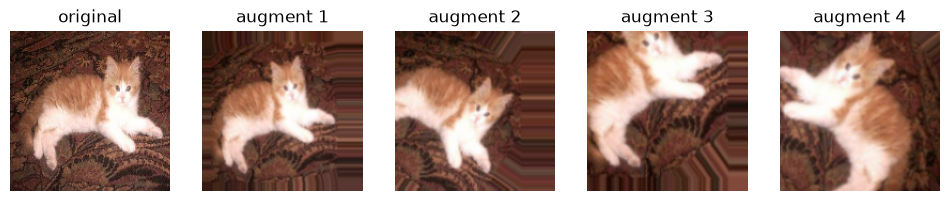

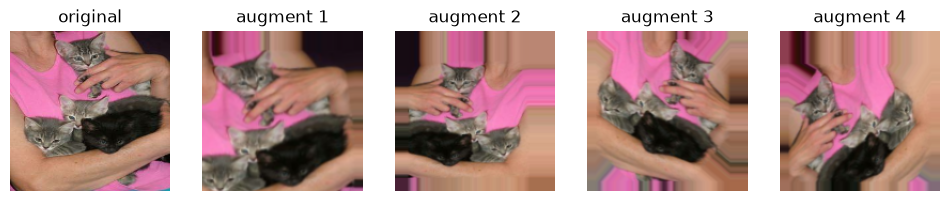

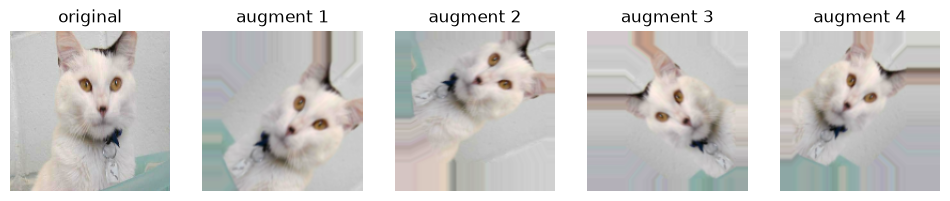

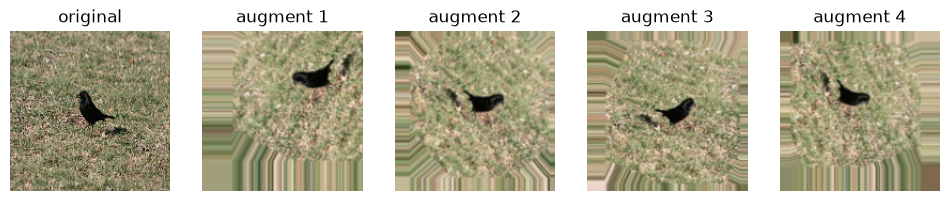

In [36]:
NUM_AUG = 4

# Apply the transformations to the first 4 images
lab_utils.demo_augmentation(sample_batch[0], data_augmentation, NUM_AUG)
lab_utils.demo_augmentation(sample_batch[1], data_augmentation, NUM_AUG)
lab_utils.demo_augmentation(sample_batch[2], data_augmentation, NUM_AUG)
lab_utils.demo_augmentation(sample_batch[3], data_augmentation, NUM_AUG)


Feel free to modify the parameters in the data augmentation model and see how it transforms the original images. Now that you know what it is doing to the training images, you can move onto training. You will prepend the data augmentation model to the base model as shown below.

In [37]:
# Instantiate the base model
base_model = lab_utils.create_model()

# Prepend the data augmentation layers to the base model
augmented_model = tf.keras.models.Sequential([
    data_augmentation,
    base_model
])

# Compile the model
augmented_model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['sparse_categorical_accuracy'])


/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
augmented_history = augmented_model.fit(
    train_dataset_final,
    epochs=40,
    validation_data=dev_dataset_final)


Epoch 1/40


/Users/rrao14/.venvml/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 1.1028 - sparse_categorical_accuracy: 0.3606 - val_loss: 1.0565 - val_sparse_categorical_accuracy: 0.3959
Epoch 2/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 1.0092 - sparse_categorical_accuracy: 0.4792 - val_loss: 1.3351 - val_sparse_categorical_accuracy: 0.3630
Epoch 3/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.9552 - sparse_categorical_accuracy: 0.5189 - val_loss: 0.9266 - val_sparse_categorical_accuracy: 0.5532
Epoch 4/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.9047 - sparse_categorical_accuracy: 0.5511 - val_loss: 0.8548 - val_sparse_categorical_accuracy: 0.5860
Epoch 5/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.8846 - sparse_categorical_accuracy: 0.5712 - val_loss: 1.0980 - val_sparse_categorical_accuracy: 0.5540
Epoch 6/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - loss: 0.9064 - sparse_categorical_accuracy: 0.5612 - val_loss: 0.9605 - val_sparse_categorical_accuracy: 0.5030
Epoch 7/40


Since you know that class imbalance is no longer an issue, you can skip checking for more in-depth metrics and instead plot the training history right away.

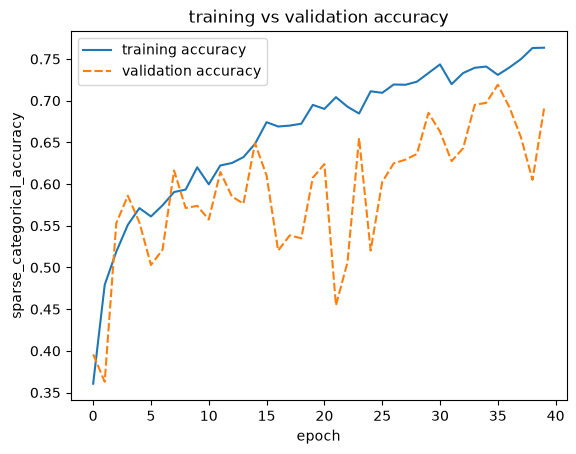

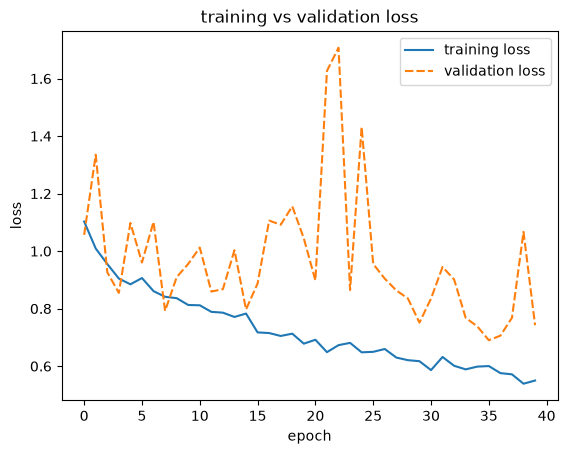

In [39]:
lab_utils.plot_train_eval(augmented_history)

Now, the validation accuracy follows the training accuracy more closely. This finding indicates that **the model is no longer overfitting**, which is quite a remarkable result achieved by just augmenting the existing images.

Another point worth mentioning is that, in this run, the augmented model actually reaches a validation accuracy (about 0.69) that is comparable to — if slightly higher than — the model without data augmentation (about 0.68), though it took many more epochs to get there and the validation curve is noticeably noisier along the way. The model needs more epochs to train because it's dealing with a lot more variations in the dataset (due to the augmentations).


## Wrapping it up

**Congratulations on finishing this ungraded lab!**

It is quite amazing to see how data alone can impact machine learning models. Hopefully, this lab helped you better understand the importance of data.

In particular, you figured out ways to diagnose the effects of class imbalance and looked at specific metrics to spot this problem. Adding more data is a simple way to overcome class imbalance. However, this solution is not always feasible in a real life scenario.

In the final section, you applied multiple geometric transformations to the images in the training dataset to generate additional data. The goal was to use data augmentation to reduce overfitting. Changing the network architecture is also an alternative method to address this problem. In practice, it is a good idea to implement both techniques for better results.


**Keep it up!**
